# importing Libraries
```python

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

# loading the hotel booking dataset

In [2]:
df=pd.read_csv('hotel_booking.csv')

In [ ]:
df

# overview of the dataset

In [4]:
df.shape

(119390, 36)

In [5]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

# we will check our problem statment and remove the columns which are not required for our analysis

In [6]:
df=df[['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'arrival_date_year', 'deposit_type', 'country', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'total_of_special_requests', 'booking_changes', 'is_repeated_guest', 'market_segment', 'customer_type']]

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_month              119390 non-null  str    
 4   arrival_date_year               119390 non-null  int64  
 5   deposit_type                    119390 non-null  str    
 6   country                         118902 non-null  str    
 7   previous_cancellations          119390 non-null  int64  
 8   previous_bookings_not_canceled  119390 non-null  int64  
 9   adr                             119390 non-null  float64
 10  total_of_special_requests       119390 non-null  int64  
 11  booking_changes                 119390 non-null  int64  
 12  is_repeated_guest          

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
previous_cancellations,119390.0,0.087118,0.844336,0.00,0.00,0.000,0.0,26.0
previous_bookings_not_canceled,119390.0,0.137097,1.497437,0.00,0.00,0.000,0.0,72.0
adr,119390.0,101.831122,50.535790,-6.38,69.29,94.575,126.0,5400.0
total_of_special_requests,119390.0,0.571363,0.792798,0.00,0.00,0.000,1.0,5.0
booking_changes,119390.0,0.221124,0.652306,0.00,0.00,0.000,0.0,21.0
is_repeated_guest,119390.0,0.031912,0.175767,0.00,0.00,0.000,0.0,1.0


# start data cleaning and preprocessing

In [16]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_month                0
arrival_date_year                 0
deposit_type                      0
country                           0
previous_cancellations            0
previous_bookings_not_canceled    0
adr                               0
total_of_special_requests         0
booking_changes                   0
is_repeated_guest                 0
market_segment                    0
customer_type                     0
dtype: int64

In [15]:
df['country']=df['country'].fillna('unkown')

# Now check the variable types and convert the variables to the required data type

In [18]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_year,deposit_type,country,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,booking_changes,is_repeated_guest,market_segment,customer_type
0,Resort Hotel,0,342,July,2015,No Deposit,PRT,0,0,0.0,0,3,0,Direct,Transient
1,Resort Hotel,0,737,July,2015,No Deposit,PRT,0,0,0.0,0,4,0,Direct,Transient
2,Resort Hotel,0,7,July,2015,No Deposit,GBR,0,0,75.0,0,0,0,Direct,Transient
3,Resort Hotel,0,13,July,2015,No Deposit,GBR,0,0,75.0,0,0,0,Corporate,Transient
4,Resort Hotel,0,14,July,2015,No Deposit,GBR,0,0,98.0,1,0,0,Online TA,Transient


In [20]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 15 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_month              119390 non-null  str    
 4   arrival_date_year               119390 non-null  int64  
 5   deposit_type                    119390 non-null  str    
 6   country                         119390 non-null  str    
 7   previous_cancellations          119390 non-null  int64  
 8   previous_bookings_not_canceled  119390 non-null  int64  
 9   adr                             119390 non-null  float64
 10  total_of_special_requests       119390 non-null  int64  
 11  booking_changes                 119390 non-null  int64  
 12  is_repeated_guest          

# 1. What is the overall cancellation rate, and how does it differ between City Hotel and Resort Hotel?

In [24]:
df.groupby('hotel')['is_canceled'].mean()*100

hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64

# use plot

<Axes: xlabel='is_canceled', ylabel='hotel'>

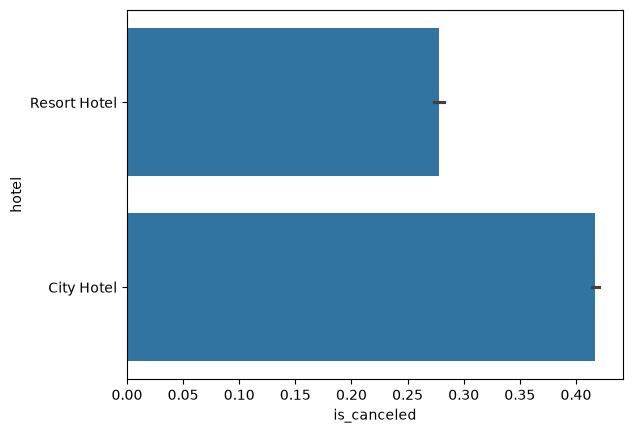

In [25]:
sns.barplot(x='is_canceled',y='hotel',data=df)

# 2. How does `lead_time` (days between booking and arrival) affect the probability of cancellation?

In [27]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

<Axes: xlabel='is_canceled', ylabel='lead_time'>

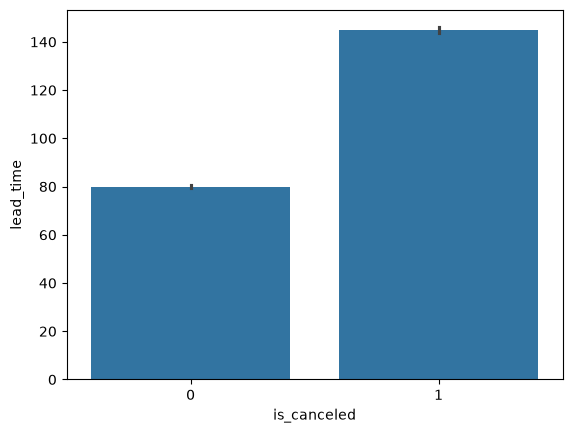

In [28]:
sns.barplot(x='is_canceled',y='lead_time',data=df)

# Which countries have the highest cancellation rates?

In [47]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month',
       'arrival_date_year', 'deposit_type', 'country',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'total_of_special_requests', 'booking_changes', 'is_repeated_guest',
       'market_segment', 'customer_type'],
      dtype='str')

In [53]:
country_cancel = df.groupby('country')['is_canceled'].agg(['mean', 'count'])
country_cancel.columns = ['cancellation_rate', 'total_bookings']
country_cancel = country_cancel.sort_values('total_bookings', ascending=False)
print(country_cancel.head(10))

         cancellation_rate  total_bookings
country                                   
PRT               0.566351           48590
GBR               0.202243           12129
FRA               0.185694           10415
ESP               0.254085            8568
DEU               0.167147            7287
ITA               0.353956            3766
IRL               0.246519            3375
BEL               0.202391            2342
BRA               0.373201            2224
NLD               0.183935            2104


<Axes: xlabel='country'>

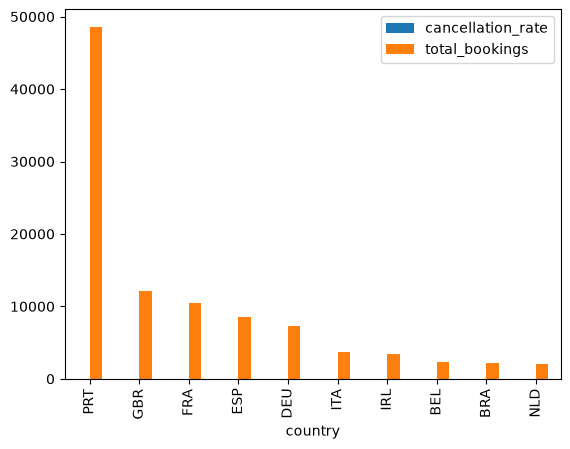

In [57]:
country_cancel.head(10).plot(kind='bar')

# What impact does `deposit_type` have on cancellation behavior?

In [65]:
effect_deposite=df.groupby('deposit_type')['is_canceled'].agg(['mean','count'])
effect_deposite.columns=['avg_cancel_dep','total_dep']


In [68]:
corr=effect_deposite.corr()

<Axes: >

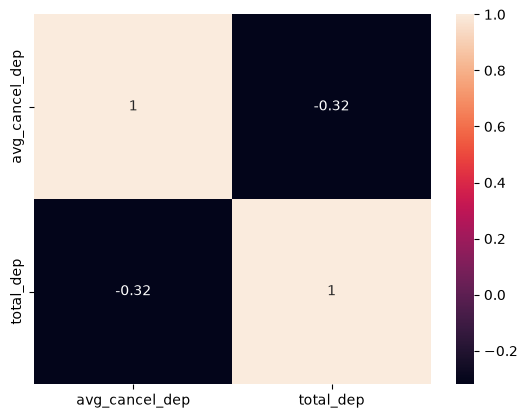

In [69]:
sns.heatmap(corr,annot=True)

# Does a guest's `previous_cancellations` history predict future cancellations?

In [71]:
df['previous_cancellations'].value_counts()

previous_cancellations
0     112906
1       6051
2        116
3         65
24        48
11        35
4         31
26        26
25        25
6         22
19        19
5         19
14        14
13        12
21         1
Name: count, dtype: int64

In [75]:
corr=df[['previous_cancellations','is_canceled']].corr()

<Axes: >

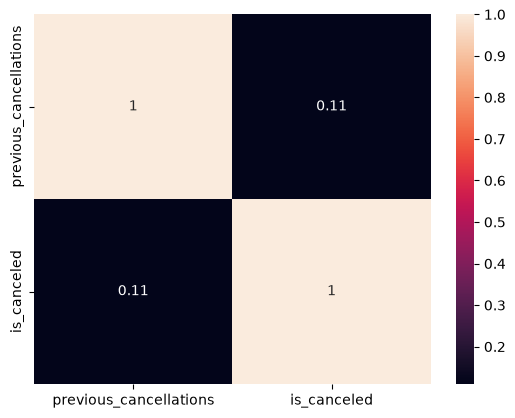

In [77]:
sns.heatmap(corr,annot=True)

<Axes: xlabel='previous_cancellations', ylabel='count'>

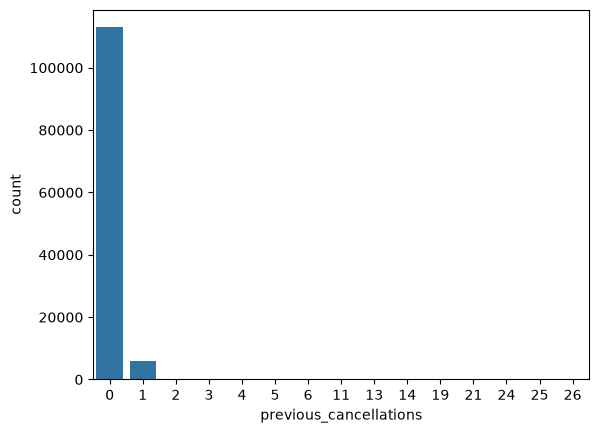

In [72]:
sns.countplot(x='previous_cancellations',data=df)

In [78]:
# Guest ko 2 groups mein baato: koi previous cancellation nahi vs kam se kam 1
df['has_prior_cancellation'] = df['previous_cancellations'].apply(lambda x: 'Yes' if x > 0 else 'No')

rate_comparison = df.groupby('has_prior_cancellation')['is_canceled'].agg(['mean', 'count'])
rate_comparison.columns = ['cancellation_rate', 'total_bookings']
print(rate_comparison)

                        cancellation_rate  total_bookings
has_prior_cancellation                                   
No                               0.339061          112906
Yes                              0.916410            6484


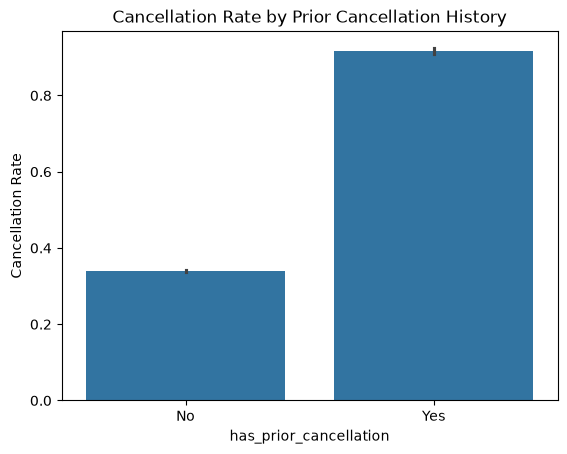

In [79]:
sns.barplot(x='has_prior_cancellation', y='is_canceled', data=df)
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Prior Cancellation History')
plt.show()

# What does a "high-risk" booking profile look like when combining multiple factors?

In [80]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_year,deposit_type,country,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,booking_changes,is_repeated_guest,market_segment,customer_type,has_prior_cancellation
0,Resort Hotel,0,342,July,2015,No Deposit,PRT,0,0,0.0,0,3,0,Direct,Transient,No
1,Resort Hotel,0,737,July,2015,No Deposit,PRT,0,0,0.0,0,4,0,Direct,Transient,No
2,Resort Hotel,0,7,July,2015,No Deposit,GBR,0,0,75.0,0,0,0,Direct,Transient,No
3,Resort Hotel,0,13,July,2015,No Deposit,GBR,0,0,75.0,0,0,0,Corporate,Transient,No
4,Resort Hotel,0,14,July,2015,No Deposit,GBR,0,0,98.0,1,0,0,Online TA,Transient,No


In [81]:
df['risk_score'] = (
    (df['lead_time'] > 100).astype(int) +
    (df['deposit_type'] == 'Non Refund').astype(int) +
    (df['previous_cancellations'] > 0).astype(int) +
    (df['total_of_special_requests'] == 0).astype(int)   # zero requests = less engaged guest
)

df['risk_score'].value_counts().sort_index()

risk_score
0    31351
1    53332
2    21631
3    10149
4     2927
Name: count, dtype: int64

In [82]:
risk_analysis = df.groupby('risk_score')['is_canceled'].agg(['mean', 'count'])
risk_analysis.columns = ['cancellation_rate', 'total_bookings']
print(risk_analysis)

            cancellation_rate  total_bookings
risk_score                                   
0                    0.180568           31351
1                    0.278744           53332
2                    0.493412           21631
3                    0.994876           10149
4                    1.000000            2927


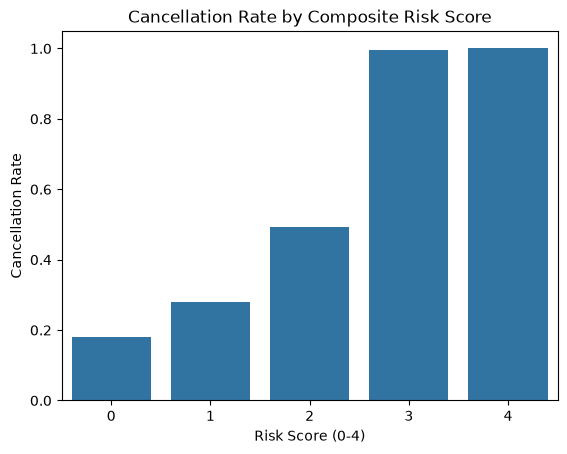

In [83]:
sns.barplot(x=risk_analysis.index, y=risk_analysis['cancellation_rate'])
plt.xlabel('Risk Score (0-4)')
plt.ylabel('Cancellation Rate')
plt.title('Cancellation Rate by Composite Risk Score')
plt.show()

In [84]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['adr'] >= Q1 - 1.5*IQR) & (df['adr'] <= Q3 + 1.5*IQR)]

In [85]:
adr_comparison = df_clean.groupby('is_canceled')['adr'].agg(['mean', 'median', 'std'])
print(adr_comparison)

                   mean  median        std
is_canceled                               
0             95.285413  90.705  41.799231
1            100.020226  95.000  38.329012


In [86]:
df_clean[['adr', 'is_canceled']].corr()

,adr,is_canceled
adr,1.000000,0.056281
is_canceled,0.056281,1.000000


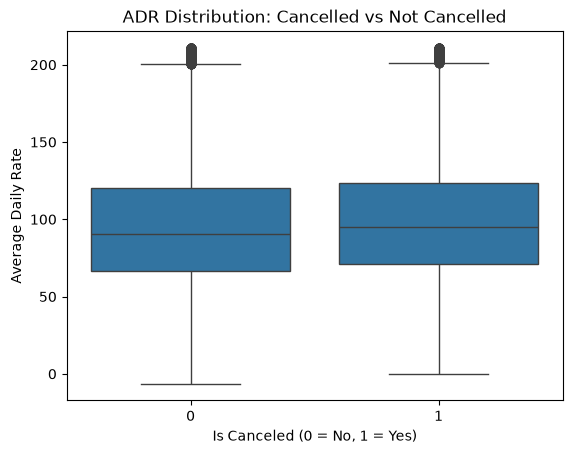

In [87]:
sns.boxplot(x='is_canceled', y='adr', data=df_clean)
plt.title('ADR Distribution: Cancelled vs Not Cancelled')
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Average Daily Rate')
plt.show()